In [1]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx

In [2]:
df = pd.read_csv('../DATA/02_image_clusters/full_image_data_feb_25.csv')

In [3]:
books = pd.read_csv('../DATA/01_corpus_metadata/full_book_data_feb_25.csv')

In [4]:
visual_tags = pd.read_excel('../DATA/04_visual_tags/visual_tags/VT_1.2_right_and_oblique_spheres.xlsx')

In [5]:
# adding printers and publishers data to "df"
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

In [6]:
#filtering

#it is not a simple command as we need all 
#the cks that are in other rows with double images values
#to be included too

target_cks = ['CK_Right and Oblique Sphere']

# Step 1: Filter the DataFrame for rows where 'cks' is in the target_cks list
filtered_df_target_cks = df[df['cks'].isin(target_cks)]

# Step 2: Get the unique 'images' values associated with the target cks
images_with_target_cks = filtered_df_target_cks['images'].unique()

# Step 3: Filter the original DataFrame to include all rows that have these images
filtered_df = df[df['images'].isin(images_with_target_cks)]

# filtered_df

In [7]:
unique_counts = pd.concat([
    df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('df'),
    filtered_df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('filtered_df')
], axis=1)

print(unique_counts)

# Assuming your DataFrame is named df and has a column named 'cks':
unique_cks = filtered_df['cks'].unique()

# To print them:
print(unique_cks)

print(visual_tags.columns)


                 df  filtered_df
images        20540          667
cluster_name   3563           47
cks             168           10
place            42           38
printer         166          141
publisher       155          130
['CK_Right and Oblique Sphere' 'CK_Horizon' 'CK_Elevation of the Pole'
 'CK_Sun Lines and Motion' 'CK_Geometry for Geometry'
 'CK_Introduction to Geometry' 'CK_Five Zones' 'CK_Terraqueous Globe'
 'CK_Armillary Sphere' 'CK_11 Spheres']
Index(['cluster_name', '3D', 'Multiple horizons', 'human figure', 'color',
       'circle', 'double image', 'diagram', 'decorated', 'material globe'],
      dtype='object')


In [8]:
#checking if all the clusters have visual tags

# Get unique values
visual_tags_clusters = set(visual_tags['cluster_name'].unique())
filtered_df_clusters = set(filtered_df['cluster_name'].unique())

# Compare
only_in_visual_tags = visual_tags_clusters - filtered_df_clusters
only_in_filtered_df = filtered_df_clusters - visual_tags_clusters
in_both = visual_tags_clusters & filtered_df_clusters

# Print results
print("Unique cluster names only in visual_tags:")
print(sorted(only_in_visual_tags))

print("\nUnique cluster names only in filtered_df:")
print(sorted(only_in_filtered_df))

# print("\nCluster names present in both:")
# print(sorted(in_both))


Unique cluster names only in visual_tags:
[]

Unique cluster names only in filtered_df:
[]


In [9]:
#merge visual tags with filtered_df on cluster_name
visual_df = pd.merge(filtered_df, visual_tags, on='cluster_name')
# visual_df

Number of Unique Books per Selected CKs Over Time:
           CK_Right and Oblique Sphere  CK_Horizon  CK_Elevation of the Pole  \
1470-1489                            6           2                       0.0   
1490-1509                           25           8                       7.0   
1510-1529                           21          12                       9.0   
1530-1549                           39          11                       5.0   
1550-1569                           71          53                       1.0   
1570-1589                           55          40                       0.0   
1590-1609                           45          37                       0.0   
1610-1629                           20          16                       5.0   
1630-1650                            4           4                       2.0   

           Books  
1470-1489     14  
1490-1509     37  
1510-1529     30  
1530-1549     48  
1550-1569     88  
1570-1589     69  
1590-1609     4

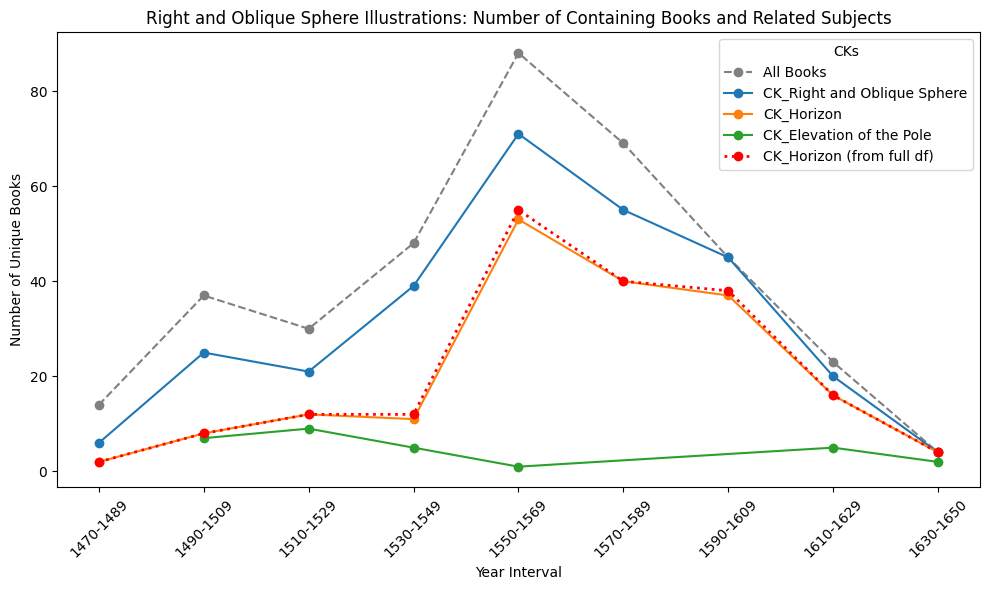

In [10]:
# === Step 1: Define Your Target CKs from filtered_df ===
target_cks = [
    'CK_Right and Oblique Sphere',
    'CK_Horizon',
    'CK_Elevation of the Pole'
]

# === Step 2: Data Preparation ===

# Count total unique books per year_interval from books
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# Define the timeline (year intervals as strings)
intervals = unique_books_count.index.astype(str)

# Count books per CK in filtered_df
book_counts = {
    keyword: (
        filtered_df[filtered_df['cks'] == keyword]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# Count books with 'CK_Horizon' from the full df (not filtered_df)
ck_horizon_data_full = (
    df[df['cks'] == 'CK_Horizon']
    .groupby('year_interval', observed=False)['book']
    .nunique()
    .to_dict()
)

# Build values aligned with timeline
ck_horizon_values_full = [ck_horizon_data_full.get(interval, 0) for interval in unique_books_count.index]

# === Step 3: Create Summary DataFrame (for optional inspection) ===
book_counts_df = pd.DataFrame(book_counts).fillna(0)
book_counts_df['Books'] = unique_books_count.values

print("Number of Unique Books per Selected CKs Over Time:")
print(book_counts_df)

# === Step 4: Plot the Results ===

plt.figure(figsize=(10, 6))

# Plot total books as a baseline
plt.plot(intervals, unique_books_count.values, label='All Books', marker='o', color='grey', linestyle='--')

# Plot each selected CK from filtered_df
for keyword, data in book_counts.items():
    keyword_values = [data.get(interval, 0) for interval in unique_books_count.index]
    non_zero_values = [val for val in keyword_values if val > 0]
    non_zero_intervals = [intervals[i] for i, val in enumerate(keyword_values) if val > 0]

    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# Plot CK_Horizon from full df
plt.plot(
    intervals,
    ck_horizon_values_full,
    marker='o',
    linestyle=':',
    linewidth=2,
    color='red',
    label='CK_Horizon (from full df)'
)

# === Step 5: Final Formatting ===

plt.title('Right and Oblique Sphere Illustrations: Number of Containing Books and Related Subjects')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='CKs')
plt.tight_layout()

# === Step 6: Show the Plot ===

# Optional: Save the plot
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_b_books_per_ck.png', dpi=300)

plt.show()


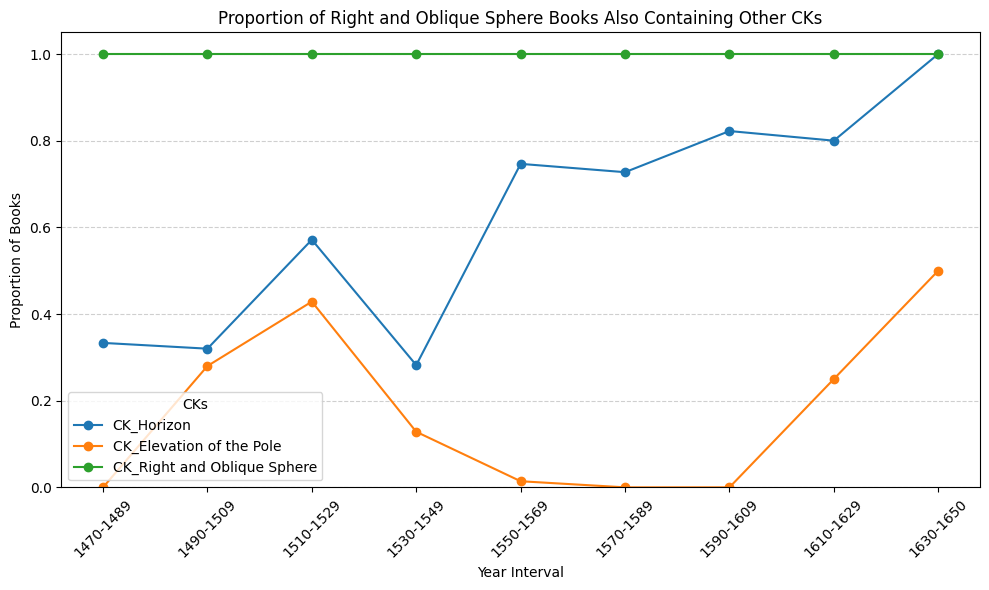

In [11]:
# === Step 1: Define Target CKs ===
target_cks = [
    'CK_Right and Oblique Sphere',
    'CK_Horizon',
    'CK_Elevation of the Pole'
]

# === Step 2: Prepare Counts ===

# Count unique books per CK per year_interval
ck_book_counts = {
    ck: (
        filtered_df[filtered_df['cks'] == ck]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )
    for ck in target_cks
}

# Extract CK_Right and Oblique Sphere counts (denominator for proportions)
right_oblique_counts = ck_book_counts['CK_Right and Oblique Sphere']

# Compute proportions for other CKs relative to CK_Right and Oblique Sphere
proportion_data = {}
for ck in target_cks[1:]:  # exclude 'CK_Right and Oblique Sphere' itself
    proportion_data[ck] = [
        (ck_book_counts[ck].get(interval, 0) / right_oblique_counts.get(interval, 1))
        if right_oblique_counts.get(interval, 0) > 0 else 0
        for interval in right_oblique_counts.keys()
    ]

# Include the Right and Oblique Sphere itself as 100% line
proportion_data['CK_Right and Oblique Sphere'] = [1 for _ in right_oblique_counts]

# Year intervals for x-axis
intervals = [str(interval) for interval in right_oblique_counts.keys()]

# === Step 3: Create Proportional Plot ===

plt.figure(figsize=(10, 6))

for ck, values in proportion_data.items():
    plt.plot(intervals, values, marker='o', label=ck)

plt.title('Proportion of Right and Oblique Sphere Books Also Containing Other CKs')
plt.xlabel('Year Interval')
plt.ylabel('Proportion of Books')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(title='CKs')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Optional: save
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_proportional_books_per_ck.png', dpi=300)

plt.show()

Number of Unique Images per Selected CKs Over Time:
           CK_Right and Oblique Sphere  CK_Horizon  CK_Elevation of the Pole  \
1470-1489                           10           2                       0.0   
1490-1509                           66          33                      15.0   
1510-1529                           58          35                      16.0   
1530-1549                           64          28                       9.0   
1550-1569                          160          97                       1.0   
1570-1589                          159         108                       0.0   
1590-1609                           96          72                       0.0   
1610-1629                           45          28                       5.0   
1630-1650                            9           5                       2.0   

           All Images  
1470-1489          11  
1490-1509          36  
1510-1529          30  
1530-1549          47  
1550-1569          87  
157

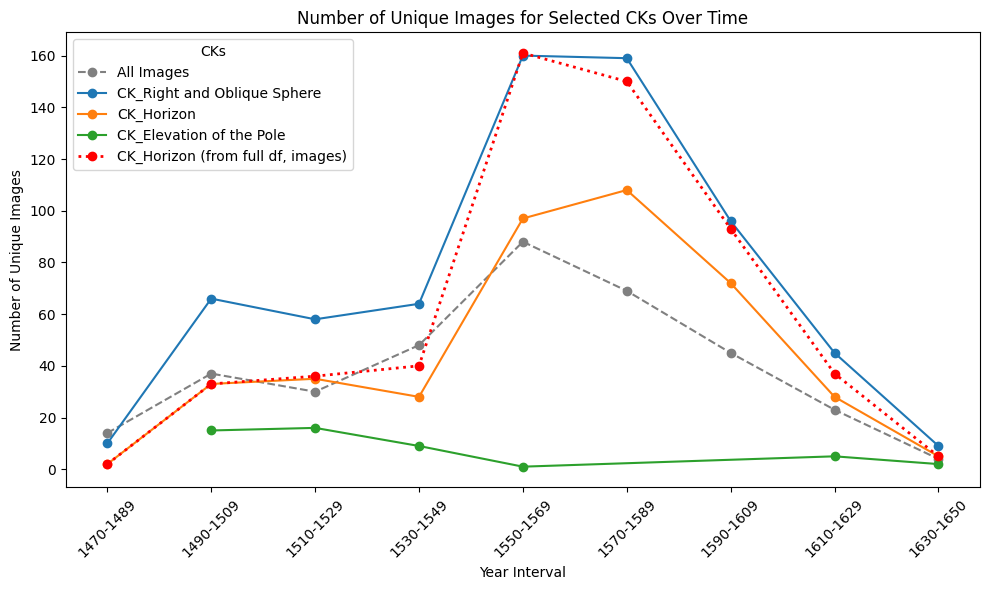

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# === Step 1: Define Your Target CKs from filtered_df ===
target_cks = [
    'CK_Right and Oblique Sphere',
    'CK_Horizon',
    'CK_Elevation of the Pole'
]

# === Step 2: Data Preparation ===

# Count total unique images per year_interval from df
unique_images_count = df.groupby('year_interval', observed=False)['book'].nunique()

# Define the timeline (year intervals as strings)
intervals = unique_images_count.index.astype(str)

# Count images per CK in filtered_df
image_counts = {
    keyword: (
        filtered_df[filtered_df['cks'] == keyword]
        .groupby('year_interval', observed=False)['images']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# Count images with 'CK_Horizon' from the full df
ck_horizon_images_full = (
    df[df['cks'] == 'CK_Horizon']
    .groupby('year_interval', observed=False)['images']
    .nunique()
    .to_dict()
)

# Build values aligned with timeline
ck_horizon_image_values_full = [ck_horizon_images_full.get(interval, 0) for interval in unique_images_count.index]

# === Step 3: Optional — Create Summary DataFrame ===
image_counts_df = pd.DataFrame(image_counts).fillna(0)
image_counts_df['All Images'] = unique_images_count.values

print("Number of Unique Images per Selected CKs Over Time:")
print(image_counts_df)

# === Step 4: Plot the Results ===

plt.figure(figsize=(10, 6))

# Plot total images as a baseline
plt.plot(intervals, unique_books_count.values, label='All Images', marker='o', color='grey', linestyle='--')

# Plot each selected CK from filtered_df
for keyword, data in image_counts.items():
    keyword_values = [data.get(interval, 0) for interval in unique_images_count.index]
    non_zero_values = [val for val in keyword_values if val > 0]
    non_zero_intervals = [intervals[i] for i, val in enumerate(keyword_values) if val > 0]

    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# Plot CK_Horizon from full df (image-based)
plt.plot(
    intervals,
    ck_horizon_image_values_full,
    marker='o',
    linestyle=':',
    linewidth=2,
    color='red',
    label='CK_Horizon (from full df, images)'
)

# === Step 5: Final Formatting ===

plt.title('Number of Unique Images for Selected CKs Over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Images')
plt.xticks(rotation=45)
plt.legend(title='CKs')
plt.tight_layout()

# === Step 6: Show the Plot ===

# Optional: Save the plot
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_b_images_per_ck.png', dpi=300)

plt.show()


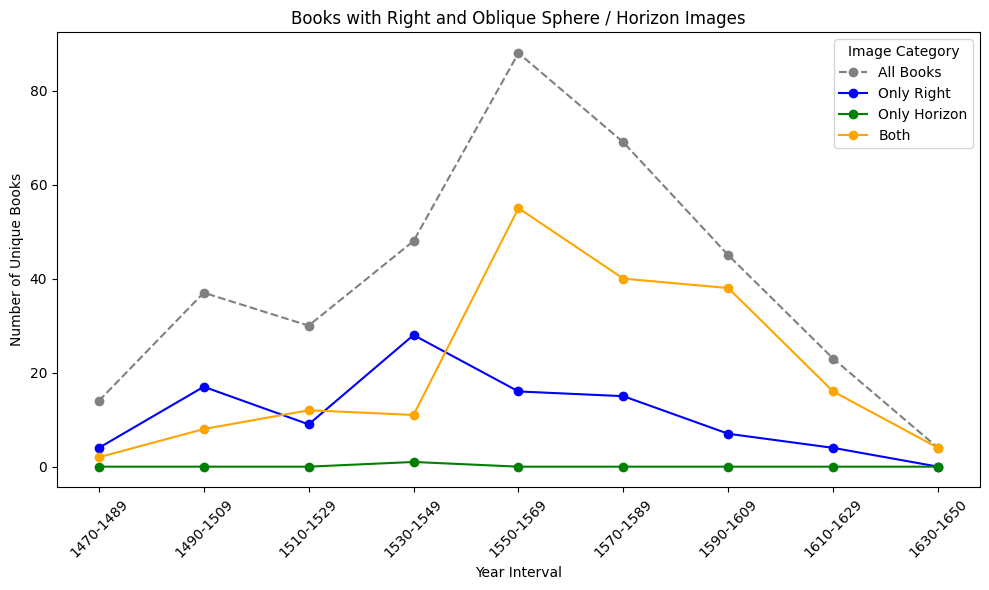

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# === Step 1: Define Your Target CKs ===
target_cks = [
    'CK_Right and Oblique Sphere',
    'CK_Horizon'
]

# === Step 2: Count total unique books per year_interval ===
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()
intervals = unique_books_count.index.astype(str)

# === Step 3: Classify books based on CK combinations ===
# Filter only the two CKs of interest
cks_per_book = (
    df[df['cks'].isin(target_cks)]
    .groupby(['year_interval', 'book'])['cks']
    .apply(set)
    .reset_index()
)

# Define function to classify books by CK combination
def classify_ck_set(ck_set):
    has_right = 'CK_Right and Oblique Sphere' in ck_set
    has_horizon = 'CK_Horizon' in ck_set
    if has_right and has_horizon:
        return 'Both'
    elif has_right:
        return 'Only Right'
    elif has_horizon:
        return 'Only Horizon'
    return 'Other'

cks_per_book['category'] = cks_per_book['cks'].apply(classify_ck_set)

# Count books in each category per year_interval
category_counts = (
    cks_per_book[cks_per_book['category'] != 'Other']
    .groupby(['year_interval', 'category'])['book']
    .nunique()
    .unstack(fill_value=0)
)

# Ensure all intervals are represented (align with unique_books_count)
category_counts = category_counts.reindex(unique_books_count.index, fill_value=0)

# === Step 4: Plotting ===

plt.figure(figsize=(10, 6))

# Plot total unique books per interval
plt.plot(
    intervals,
    unique_books_count.values,
    label='All Books',
    marker='o',
    linestyle='--',
    color='grey'
)

# Plot categorized lines
color_map = {
    'Only Right': 'blue',
    'Only Horizon': 'green',
    'Both': 'orange'
}

for category in ['Only Right', 'Only Horizon', 'Both']:
    if category in category_counts.columns:
        plt.plot(
            intervals,
            category_counts[category].values,
            label=category,
            marker='o',
            color=color_map[category]
        )

# === Step 5: Final Formatting ===

plt.title('Books with Right and Oblique Sphere / Horizon Images')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Image Category')
plt.tight_layout()

# Optional: Save plot
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_b_books_per_ck.png', dpi=300)

# Show the plot
plt.show()


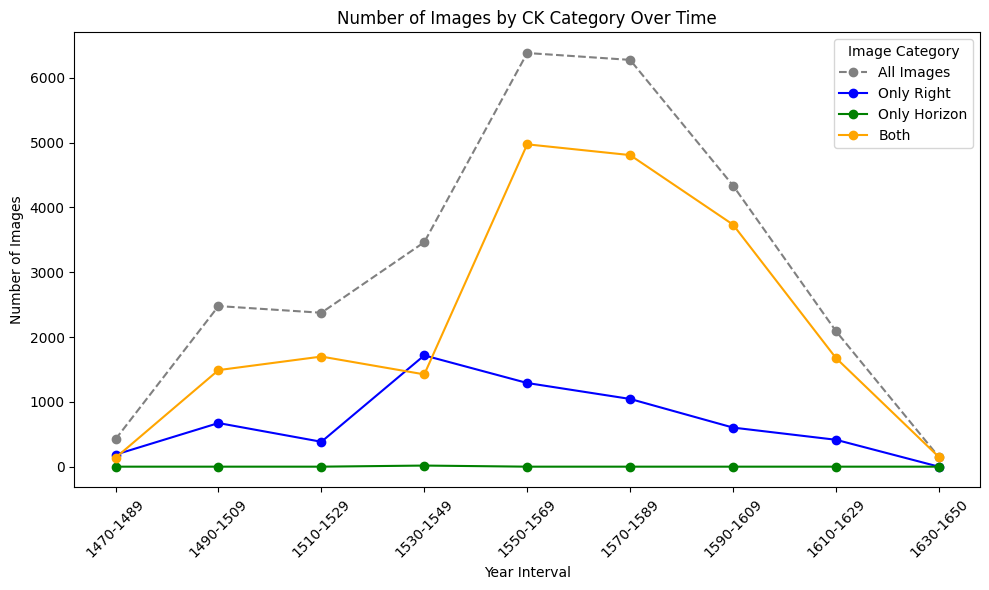

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# === Step 1: Define Target CKs ===
target_cks = ['CK_Right and Oblique Sphere', 'CK_Horizon']

# === Step 2: Classify each book by CK presence ===
# Get the set of CKs per book per year
cks_per_book = (
    df[df['cks'].isin(target_cks)]
    .groupby(['year_interval', 'book'])['cks']
    .apply(set)
    .reset_index()
)

# Define classification function
def classify_ck_set(ck_set):
    has_right = 'CK_Right and Oblique Sphere' in ck_set
    has_horizon = 'CK_Horizon' in ck_set
    if has_right and has_horizon:
        return 'Both'
    elif has_right:
        return 'Only Right'
    elif has_horizon:
        return 'Only Horizon'
    return 'Other'

cks_per_book['category'] = cks_per_book['cks'].apply(classify_ck_set)

# Create a mapping of (year_interval, book) to category
book_category_map = cks_per_book.set_index(['year_interval', 'book'])['category'].to_dict()

# === Step 3: Assign category to each image ===
def get_category(row):
    return book_category_map.get((row['year_interval'], row['book']), 'Other')

df['category'] = df.apply(get_category, axis=1)

# === Step 4: Count number of images per category per year_interval ===
image_counts = (
    df[df['category'].isin(['Only Right', 'Only Horizon', 'Both'])]
    .groupby(['year_interval', 'category'])
    .size()
    .unstack(fill_value=0)
)

# Count total images per year_interval as baseline
total_images = df.groupby('year_interval').size()

# Ensure all year_intervals are aligned
image_counts = image_counts.reindex(total_images.index, fill_value=0)
intervals = total_images.index.astype(str)

# === Step 5: Plotting ===
plt.figure(figsize=(10, 6))

# Plot total number of images
plt.plot(intervals, total_images.values, label='All Images', color='grey', linestyle='--', marker='o')

# Plot per category
color_map = {
    'Only Right': 'blue',
    'Only Horizon': 'green',
    'Both': 'orange'
}

for category in ['Only Right', 'Only Horizon', 'Both']:
    if category in image_counts.columns:
        plt.plot(
            intervals,
            image_counts[category].values,
            label=category,
            color=color_map[category],
            marker='o'
        )

# === Step 6: Final Formatting ===
plt.title('Number of Images by CK Category Over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.legend(title='Image Category')
plt.tight_layout()

# Save plot
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_c_images_per_ck.png', dpi=300)

# Show the plot
plt.show()


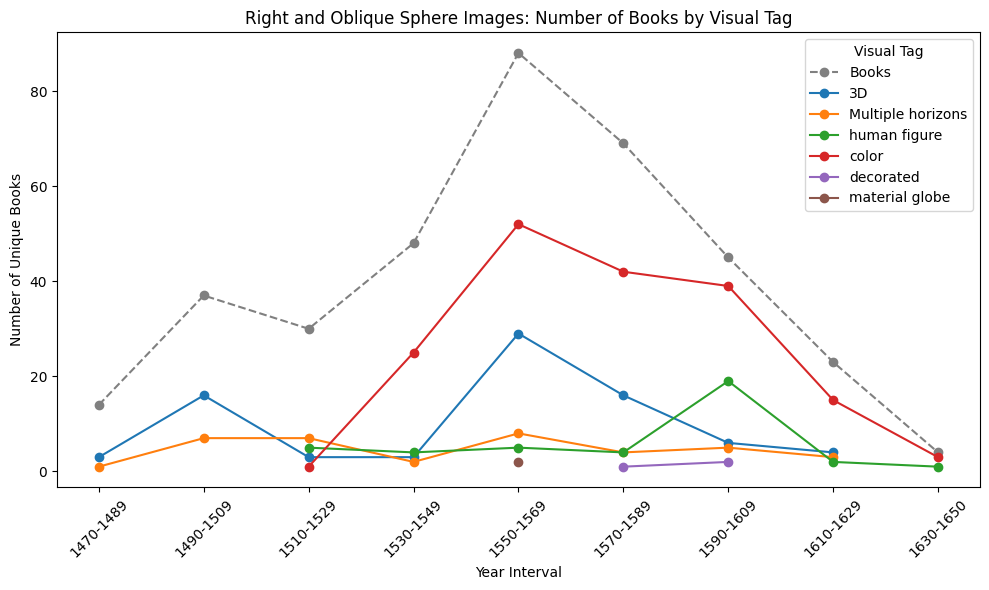

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# === Step 1: Define Tags and Prepare Data ===
defined_columns = ['3D', 'Multiple horizons', 'human figure', 'color','decorated', 'material globe']  # Replace with your actual visual tag column names

# Create a dictionary to hold the counts per tag
visual_tag_counts = {}

for col in defined_columns:
    yes_per_interval = (
        visual_df[visual_df[col] == 'yes']
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .reindex(unique_books_count.index, fill_value=0)
    )
    visual_tag_counts[col] = yes_per_interval

# === Step 2: Plotting ===

plt.figure(figsize=(10, 6))  # Set up the plot after data is ready

# Plot number of books per interval
plt.plot(unique_books_count.index.astype(str), unique_books_count.values, label='Books', marker='o', color='grey', linestyle='--')

# Plot each visual tag
for col, series in visual_tag_counts.items():
    # Filter out zero values before plotting
    non_zero_intervals = [interval for interval, val in zip(series.index.astype(str), series.values) if val > 0]
    non_zero_values = [val for val in series.values if val > 0]

    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=col)

# === Step 3: Final Formatting ===

plt.title('Right and Oblique Sphere Images: Number of Books by Visual Tag')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Visual Tag')
plt.tight_layout()

# Save and show
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.2_b_visual_right_oblique.png', dpi=300)
plt.show()


In [18]:
# === Build edges robustly ===

# Define which CKs and visual tags to include
target_cks = ['CK_Right and Oblique Sphere', 'CK_Horizon']  # <- Customize this
visual_tags = ['3D', 'Multiple horizons', 'human figure', 'color', 'decorated', 'material globe']

# === Build edges from boolean visual tags ===
edges = []
missing_tags = []

# Step 1: Edges for visual tags (from boolean columns)
for tag in visual_tags:
    if tag in visual_df.columns:
        tag_mask = visual_df[tag].astype(bool)
        tagged_places = visual_df.loc[tag_mask, 'place'].dropna()
        print(f"Visual Tag '{tag}' has {len(tagged_places)} associated places.")
        edges.extend([(place, tag) for place in tagged_places])
    else:
        missing_tags.append(tag)

# Step 2: Edges for CKs (from 'cks' column values)
for ck in target_cks:
    ck_df = visual_df[visual_df['cks'] == ck]
    tagged_places = ck_df['place'].dropna()
    print(f"CK '{ck}' has {len(tagged_places)} associated places.")
    edges.extend([(place, ck) for place in tagged_places])

# Final checks
if missing_tags:
    print("⚠️ These visual tag columns were not found in visual_df:", missing_tags)
if not edges:
    print("❌ No edges were created — double-check tag values or column names.")


Visual Tag '3D' has 1301 associated places.
Visual Tag 'Multiple horizons' has 1301 associated places.
Visual Tag 'human figure' has 1301 associated places.
Visual Tag 'color' has 1301 associated places.
Visual Tag 'decorated' has 1301 associated places.
Visual Tag 'material globe' has 1301 associated places.
CK 'CK_Right and Oblique Sphere' has 667 associated places.
CK 'CK_Horizon' has 408 associated places.


Visual Tag '3D' has 1301 associated places.
Visual Tag 'Multiple horizons' has 1301 associated places.
Visual Tag 'human figure' has 1301 associated places.
Visual Tag 'color' has 1301 associated places.
Visual Tag 'decorated' has 1301 associated places.
Visual Tag 'material globe' has 1301 associated places.
CK 'CK_Right and Oblique Sphere' has 667 associated places.
CK 'CK_Horizon' has 408 associated places.


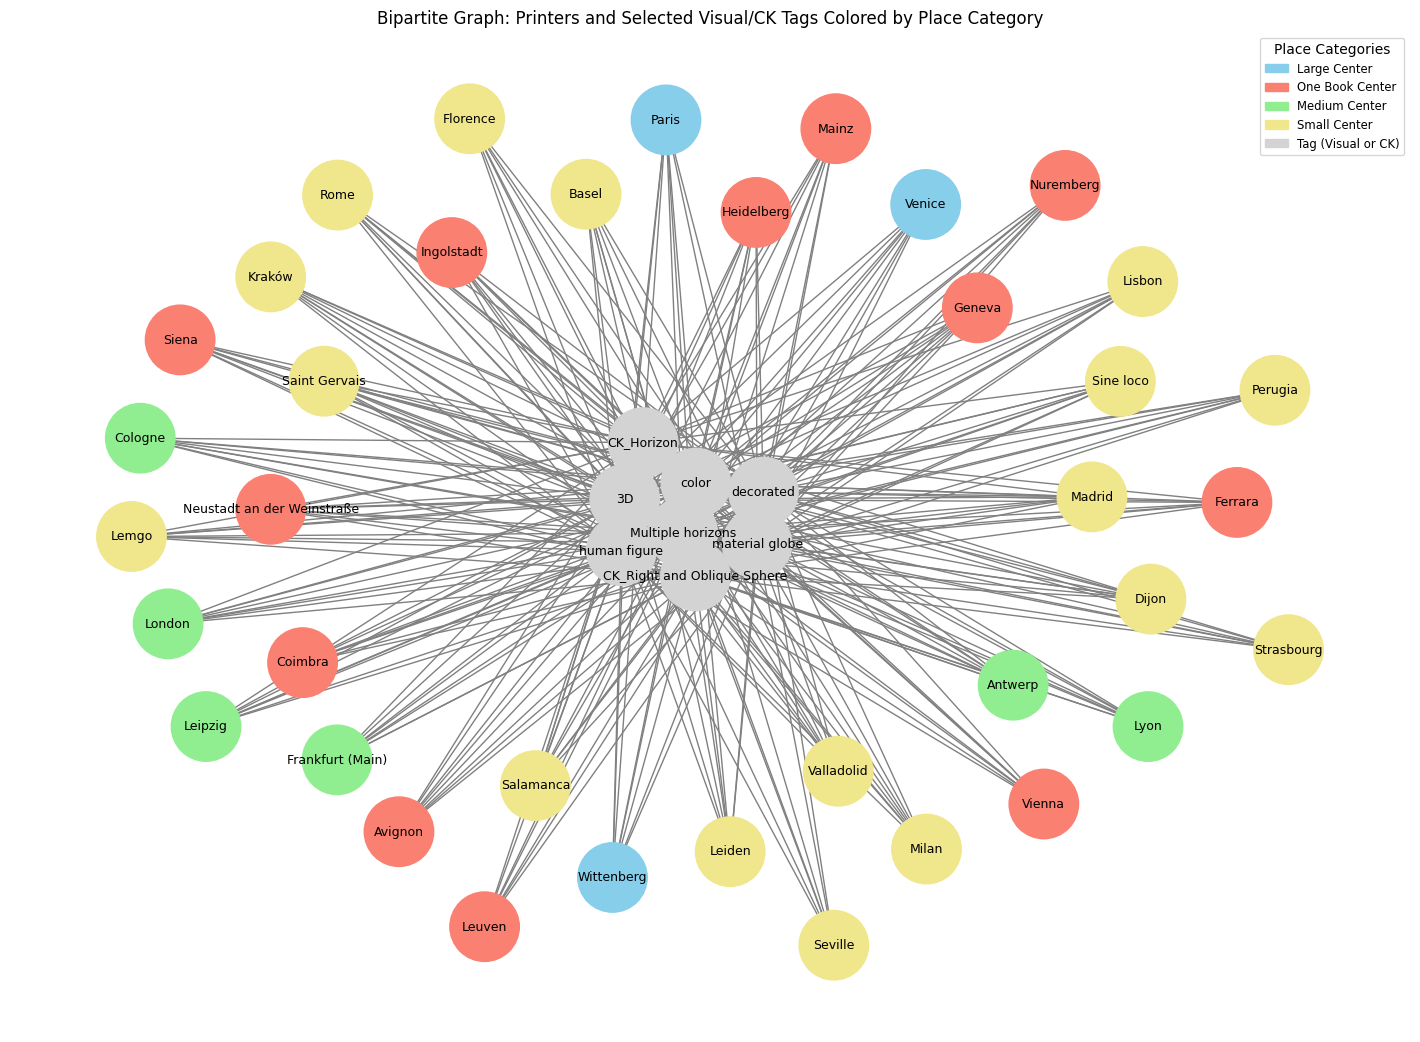

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# === Define CKs you want to include ===
target_cks = ['CK_Right and Oblique Sphere', 'CK_Horizon']  # Customize as needed

# === Define visual tags ===
visual_tags = ['3D', 'Multiple horizons', 'human figure', 'color', 'decorated', 'material globe']

# === Combine all tags ===
all_tags = visual_tags + target_cks

# === Filter places from visual_df ===
places = visual_df['place'].dropna().unique().tolist()

# === Get unique place categories and assign colors ===
unique_categories = visual_df['place_category'].dropna().unique()
category_color_map = {
    cat: color for cat, color in zip(unique_categories, ['skyblue', 'salmon', 'lightgreen', 'khaki'])
}

# === Create a place-to-color mapping based on category ===
place_color_map = {}
for place in places:
    place_rows = visual_df[visual_df['place'] == place]
    if not place_rows.empty:
        category = place_rows['place_category'].iloc[0]
        place_color_map[place] = category_color_map.get(category, 'gray')
    else:
        place_color_map[place] = 'gray'

# === Build edges ===
edges = []
missing_tags = []

# Step 1: Add edges from visual tag columns
for tag in visual_tags:
    if tag in visual_df.columns:
        tag_mask = visual_df[tag].astype(bool)
        tagged_places = visual_df.loc[tag_mask, 'place'].dropna()
        print(f"Visual Tag '{tag}' has {len(tagged_places)} associated places.")
        edges.extend([(place, tag) for place in tagged_places])
    else:
        missing_tags.append(tag)

# Step 2: Add edges from CKs found in the 'cks' column
for ck in target_cks:
    ck_df = visual_df[visual_df['cks'] == ck]
    tagged_places = ck_df['place'].dropna()
    print(f"CK '{ck}' has {len(tagged_places)} associated places.")
    edges.extend([(place, ck) for place in tagged_places])

# Final checks
if missing_tags:
    print("⚠️ These visual tag columns were not found in visual_df:", missing_tags)
if not edges:
    print("❌ No edges were created — double-check tag values or column names.")

# === Build and draw the graph ===
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(all_tags, bipartite=1)
G.add_edges_from(edges)

# === Node coloring ===
node_colors = []
for node in G.nodes():
    if node in places:
        node_colors.append(place_color_map.get(node, 'gray'))  # printer node
    else:
        node_colors.append('lightgray')  # tag node (visual/cks)

# === Draw the graph ===
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# === Legend ===
legend_handles = [mpatches.Patch(color=color, label=cat) for cat, color in category_color_map.items()]
legend_handles.append(mpatches.Patch(color='lightgray', label='Tag (Visual or CK)'))

plt.legend(handles=legend_handles, title='Place Categories', loc='upper right', fontsize='small', title_fontsize='medium')
plt.title("Bipartite Graph: Printers and Selected Visual/CK Tags Colored by Place Category")

# Optional: Save
# plt.savefig('/path/to/save/graph.png', dpi=300)

plt.show()


Visual Tag '3D' linked to 1301 printers.
Visual Tag 'Multiple horizons' linked to 1301 printers.
Visual Tag 'human figure' linked to 1301 printers.
Visual Tag 'color' linked to 1301 printers.
Visual Tag 'decorated' linked to 1301 printers.
Visual Tag 'material globe' linked to 1301 printers.
CK 'CK_Right and Oblique Sphere' linked to 667 printers.
CK 'CK_Horizon' linked to 408 printers.


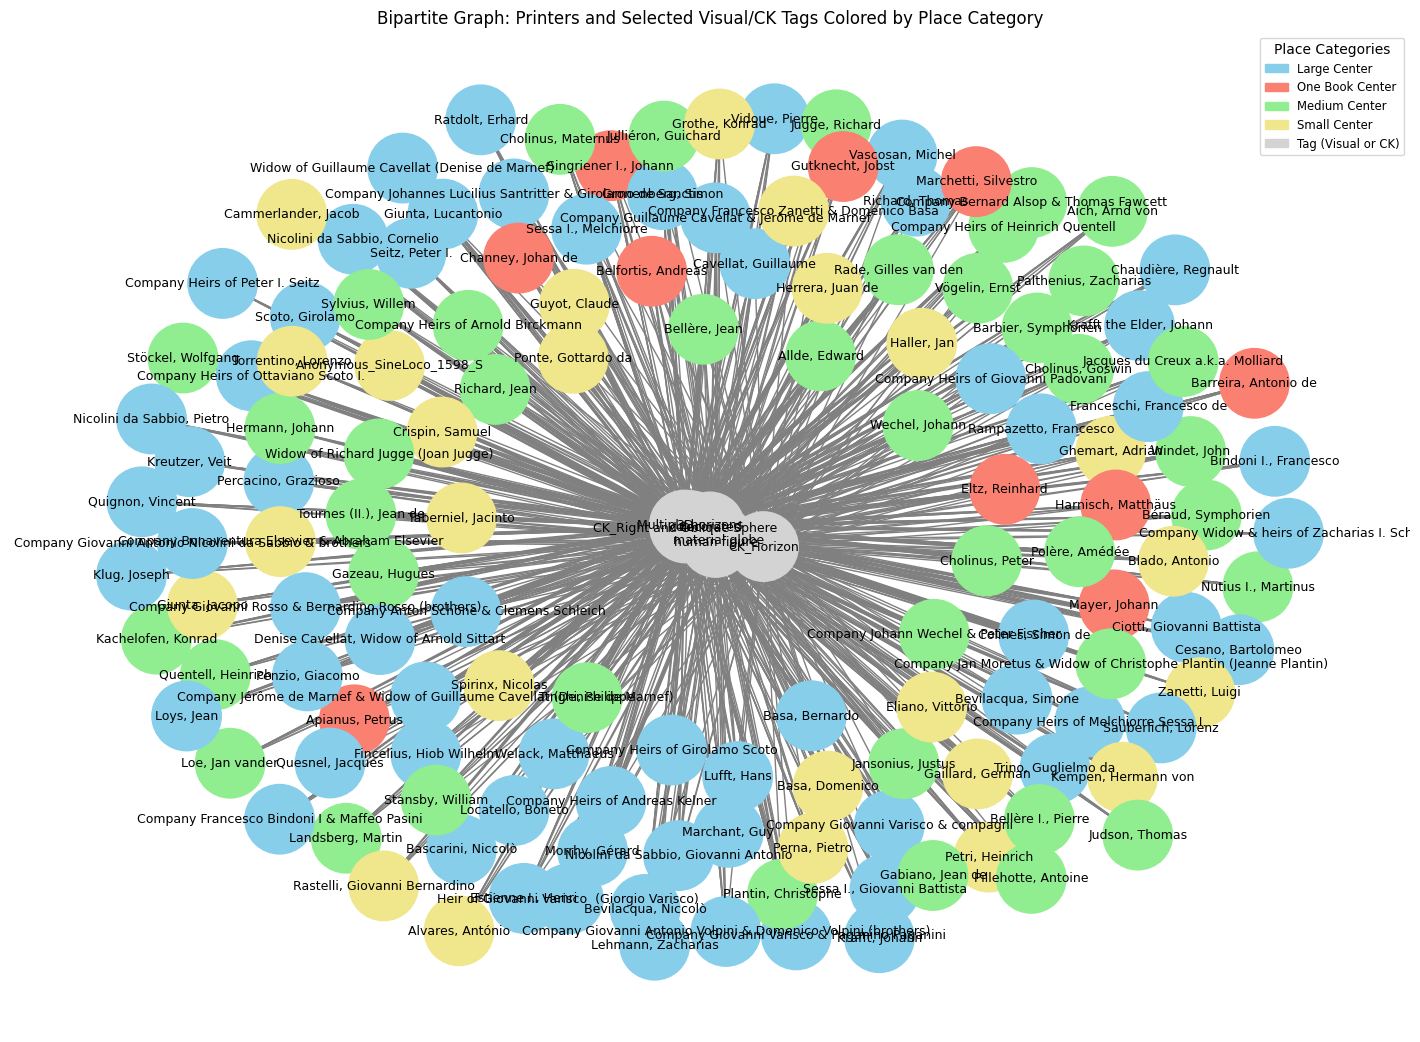

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# === Define CKs you want to include ===
target_cks = ['CK_Right and Oblique Sphere', 'CK_Horizon']

# === Define visual tags ===
visual_tags = ['3D', 'Multiple horizons', 'human figure', 'color', 'decorated', 'material globe']

# === Combine all tags ===
all_tags = visual_tags + target_cks

# === Get unique printers ===
printers = visual_df['printer'].dropna().unique().tolist()

# === Map printer to place_category ===
unique_categories = visual_df['place_category'].dropna().unique()
category_color_map = {
    cat: color for cat, color in zip(unique_categories, ['skyblue', 'salmon', 'lightgreen', 'khaki'])
}

# Build printer-to-category map
printer_color_map = {}
for printer in printers:
    rows = visual_df[visual_df['printer'] == printer]
    if not rows.empty:
        category = rows['place_category'].iloc[0]
        printer_color_map[printer] = category_color_map.get(category, 'gray')
    else:
        printer_color_map[printer] = 'gray'

# === Build edges ===
edges = []
missing_tags = []

# Step 1: Visual tag edges from boolean columns
for tag in visual_tags:
    if tag in visual_df.columns:
        tag_mask = visual_df[tag].astype(bool)
        tagged_printers = visual_df.loc[tag_mask, 'printer'].dropna()
        print(f"Visual Tag '{tag}' linked to {len(tagged_printers)} printers.")
        edges.extend([(printer, tag) for printer in tagged_printers])
    else:
        missing_tags.append(tag)

# Step 2: CK edges from 'cks' column
for ck in target_cks:
    ck_df = visual_df[visual_df['cks'] == ck]
    tagged_printers = ck_df['printer'].dropna()
    print(f"CK '{ck}' linked to {len(tagged_printers)} printers.")
    edges.extend([(printer, ck) for printer in tagged_printers])

# Checks
if missing_tags:
    print("⚠️ These visual tag columns were not found:", missing_tags)
if not edges:
    print("❌ No edges were created.")

# === Build graph ===
G = nx.Graph()
G.add_nodes_from(printers, bipartite=0)
G.add_nodes_from(all_tags, bipartite=1)
G.add_edges_from(edges)

# === Node colors ===
node_colors = []
for node in G.nodes():
    if node in printers:
        node_colors.append(printer_color_map.get(node, 'gray'))
    else:
        node_colors.append('lightgray')  # tag nodes

# === Draw ===
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# === Legend ===
legend_handles = [mpatches.Patch(color=color, label=cat) for cat, color in category_color_map.items()]
legend_handles.append(mpatches.Patch(color='lightgray', label='Tag (Visual or CK)'))

plt.legend(handles=legend_handles, title='Place Categories', loc='upper right', fontsize='small', title_fontsize='medium')
plt.title("Bipartite Graph: Printers and Selected Visual/CK Tags Colored by Place Category")

# Optional save
# plt.savefig('/path/to/save/printer_network.png', dpi=300)
plt.show()


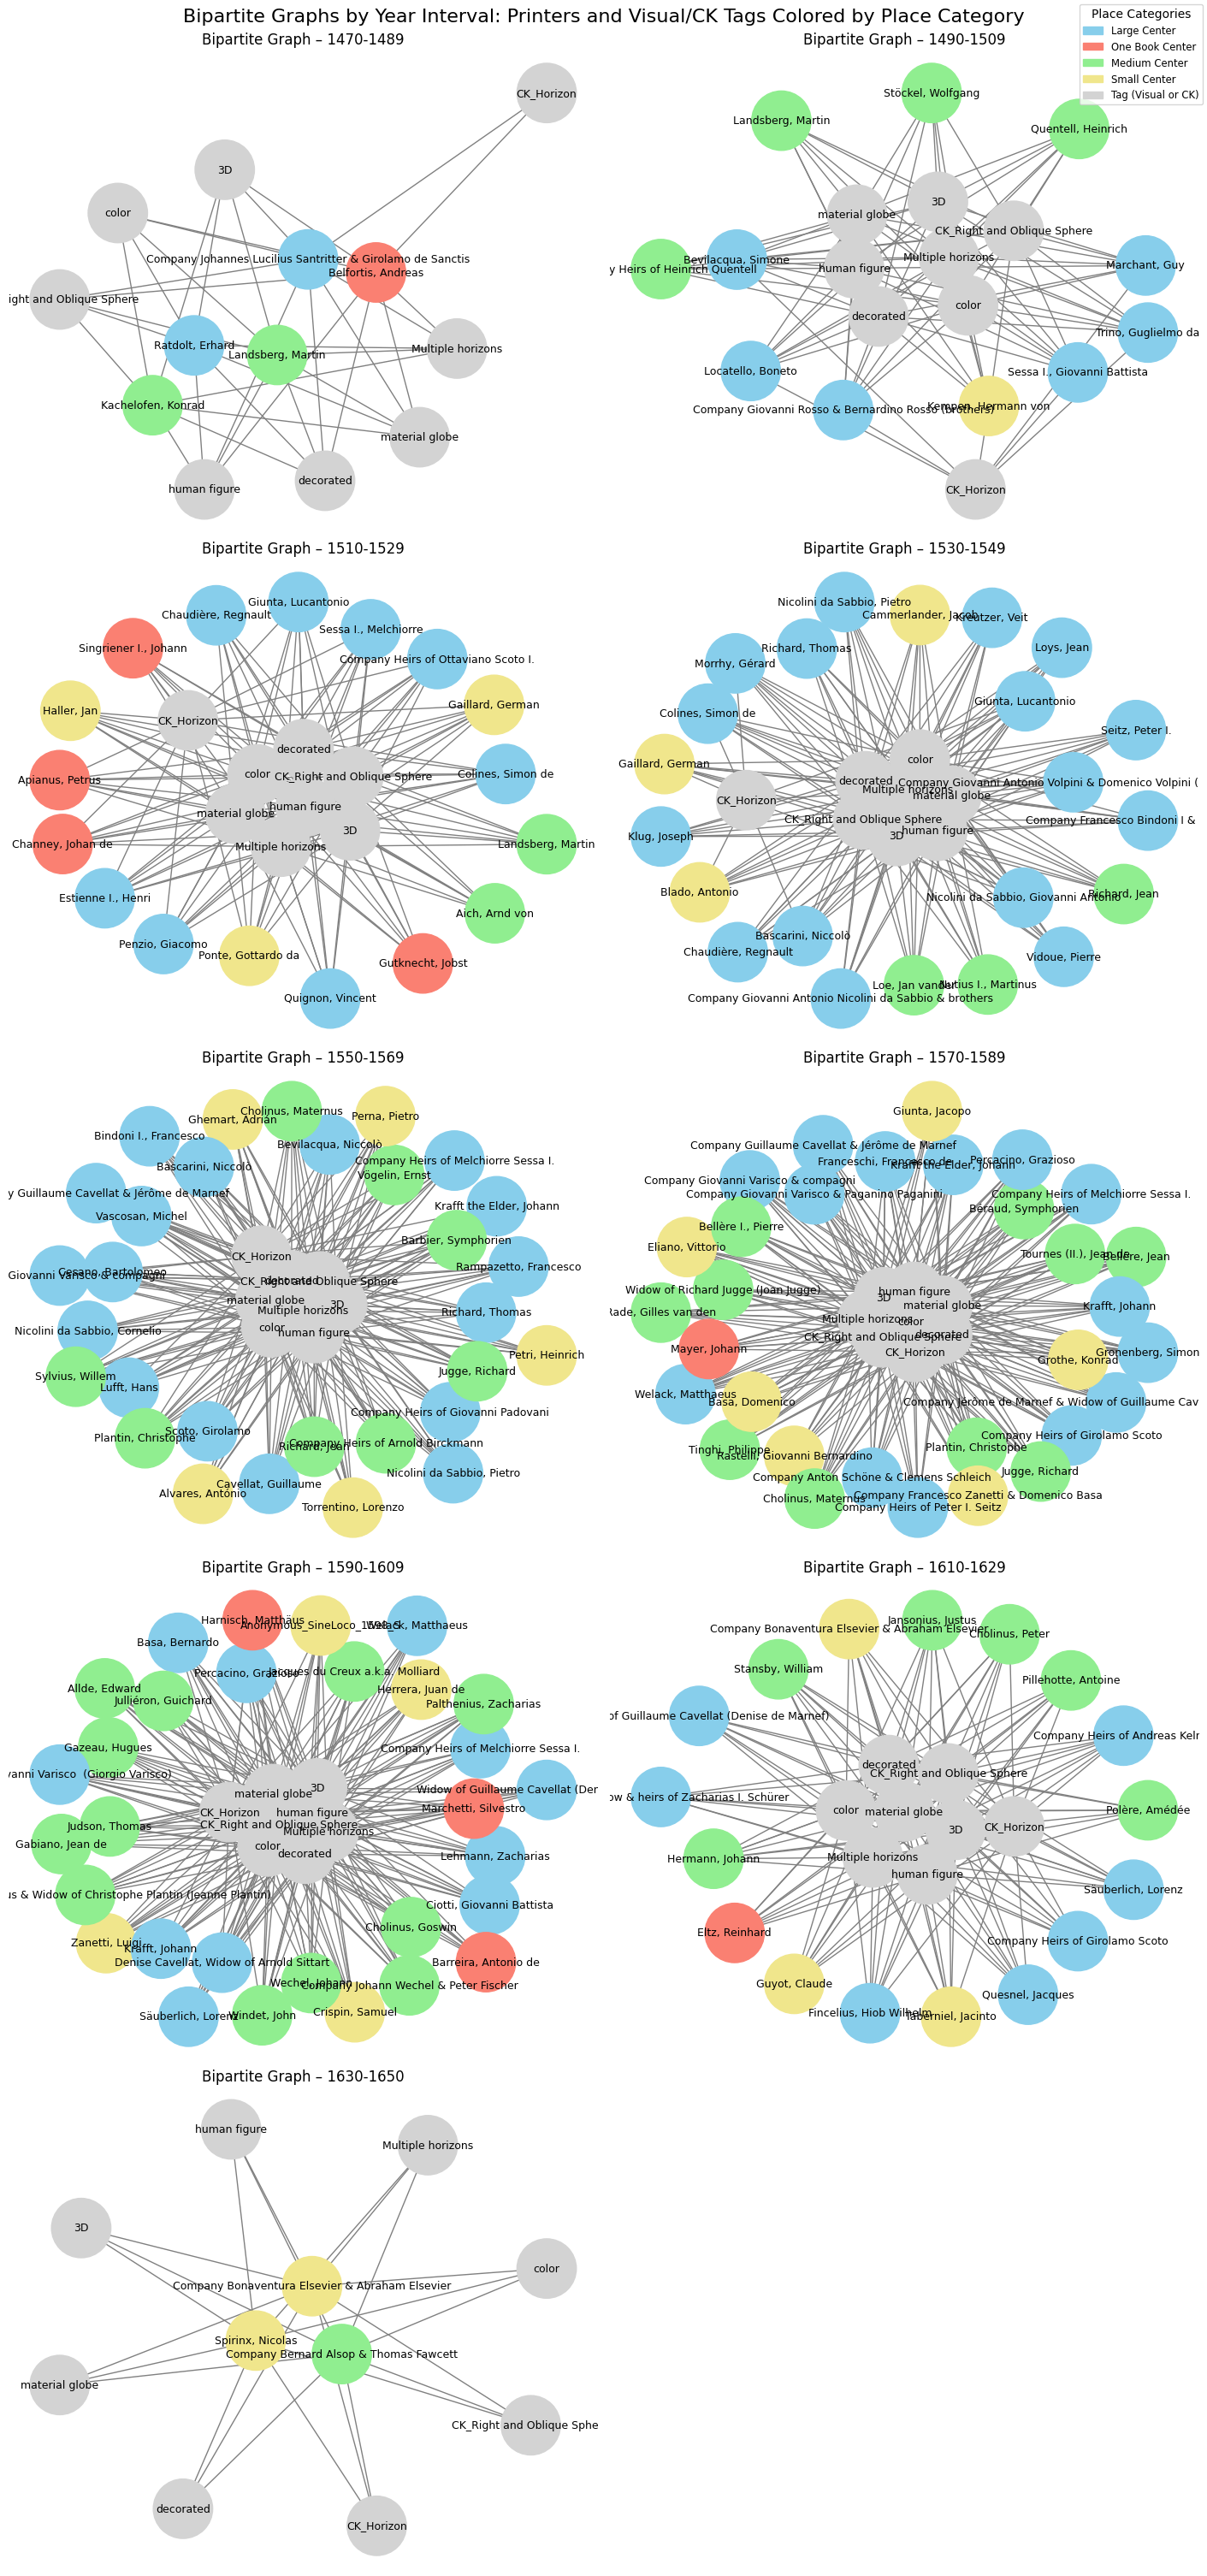

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# === Define CKs and Visual Tags ===
target_cks = ['CK_Right and Oblique Sphere', 'CK_Horizon']
visual_tags = ['3D', 'Multiple horizons', 'human figure', 'color', 'decorated', 'material globe']
all_tags = visual_tags + target_cks

# === Category color mapping ===
unique_categories = visual_df['place_category'].dropna().unique()
category_color_map = {
    cat: color for cat, color in zip(unique_categories, ['skyblue', 'salmon', 'lightgreen', 'khaki'])
}

# === Get unique intervals ===
intervals = sorted(visual_df['year_interval'].dropna().unique())

# === Set up subplots ===
n_cols = 2
n_rows = (len(intervals) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows), constrained_layout=True)
axes = axes.flatten()

for i, interval in enumerate(intervals):
    ax = axes[i]
    df_interval = visual_df[visual_df['year_interval'] == interval]

    # Get printers for this interval
    printers = df_interval['printer'].dropna().unique().tolist()

    # Build printer-to-category color map
    printer_color_map = {}
    for printer in printers:
        rows = df_interval[df_interval['printer'] == printer]
        if not rows.empty:
            category = rows['place_category'].iloc[0]
            printer_color_map[printer] = category_color_map.get(category, 'gray')
        else:
            printer_color_map[printer] = 'gray'

    # === Build edges ===
    edges = []
    for tag in visual_tags:
        if tag in df_interval.columns:
            tag_mask = df_interval[tag].astype(bool)
            tagged_printers = df_interval.loc[tag_mask, 'printer'].dropna()
            edges.extend([(printer, tag) for printer in tagged_printers])

    for ck in target_cks:
        ck_df = df_interval[df_interval['cks'] == ck]
        tagged_printers = ck_df['printer'].dropna()
        edges.extend([(printer, ck) for printer in tagged_printers])

    # === Build graph ===
    G = nx.Graph()
    G.add_nodes_from(printers, bipartite=0)
    G.add_nodes_from(all_tags, bipartite=1)
    G.add_edges_from(edges)

    # === Node colors ===
    node_colors = []
    for node in G.nodes():
        if node in printers:
            node_colors.append(printer_color_map.get(node, 'gray'))
        else:
            node_colors.append('lightgray')

    # === Draw graph ===
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=node_colors,
        edge_color='gray',
        node_size=2500,
        font_size=9,
        ax=ax
    )
    ax.set_title(f"Bipartite Graph – {interval}", fontsize=12)
    ax.axis('off')

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# === Legend ===
legend_handles = [mpatches.Patch(color=color, label=cat) for cat, color in category_color_map.items()]
legend_handles.append(mpatches.Patch(color='lightgray', label='Tag (Visual or CK)'))

fig.legend(handles=legend_handles, title='Place Categories', loc='upper right', fontsize='small', title_fontsize='medium')
plt.suptitle("Bipartite Graphs by Year Interval: Printers and Visual/CK Tags Colored by Place Category", fontsize=16)

plt.show()
